# Pauli Propagation

In [2]:
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp, commutator

import math
from functools import partial
import numpy as np
from numpy.linalg import matrix_power
from matplotlib import pyplot as plt

from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf, expH
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from pauli import *

fig_dir, data_dir = './figs', './data'
set_fontsize(linewidth=2.0)

## 2-norm dynamics

In [ ]:
## Hmiltonian, Trotter, and initial state

# n = 10
n = 8
# t_num = 50
t_num = 200
t = n
hx, hy, Jx = 1, 0.9, 0.8
print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
# qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qimf = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par

r = t_num
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_list), dt, use_jax=False)
U_dt_appro = pf(H_list, dt, 1, 1)
init_state_str = '0'*n
# init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

# z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1) + SparsePauliOp('I'*(n-3)+'XXZ', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1)
z1 = SparsePauliOp('I'*(n-2)+'XX', 1) + SparsePauliOp('I'*(n-1)+'X', 1)
commutator(qimf.ham[0], qimf.ham[3]).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j]))

ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal, i)@init_state) for i in range(r)]

QIMF model with hx=1, hy=0.9, Jx=0.8, n=8
t=8, r=200, dt=0.04


cumulative_norm_steps: [[2.0, 1.0, 0, 0, 0, 0, 0, 0], [2.0, 0.9999790510191775, 0, 0, 0, 0, 0, 0], [1.9999999999999998, 0.9998185773226071, 0.00018683695352863014, 0, 0, 0, 0, 0], [2.000000000000207, 0.9993112773788054, 0.0007304446247001427, 1.0759792488277703e-08, 0, 0, 0, 0], [2.0000000000004716, 0.9982183234665996, 0.001968908018190067, 9.383094789718952e-08, 4.3505756510723055e-13, 0, 0, 0], [2.0000000000004965, 0.9963419027195024, 0.00426961818227241, 4.915612415039998e-07, 6.7408702845783305e-12, 0, 0, 0], [2.000000000000688, 0.993603035767782, 0.008014476203527542, 1.8800874825868442e-06, 5.7748999013136214e-11, 1.847907130033839e-16, 0, 0], [2.0000000000008136, 0.9901111957750716, 0.013567023935454177, 5.79259775874094e-06, 3.426463480052265e-10, 3.7441992831475595e-15, 0, 0], [2.0000000000009095, 0.9862138726811879, 0.021247298688091314, 1.5231541540162123e-05, 1.5690840694733662e-09, 3.870156791508872e-14, 0, 0], [2.000000000001016, 0.9825168574228861, 0.031317556842920986, 

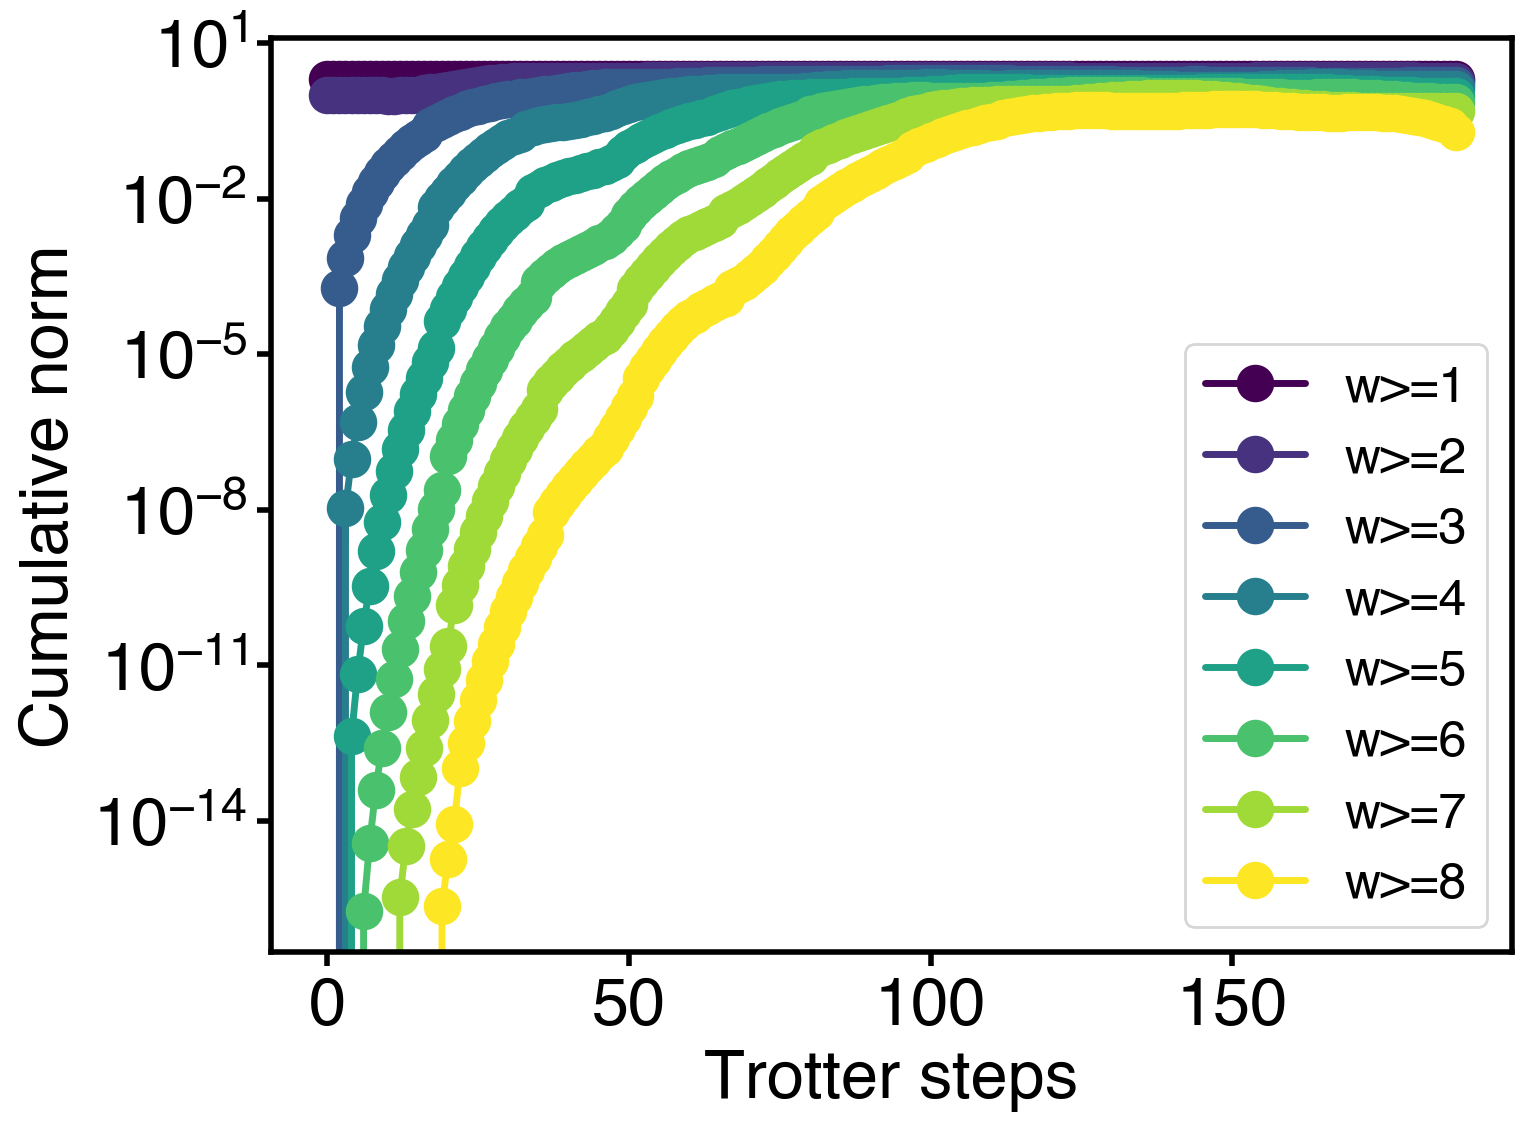

In [ ]:
## observable evolution
evo_ob = [z1]
for i in range(r):
    print('+', end='')
    for g in list(qimf.ham):
        # print(g)
        temp = []
        for item in list(evo_ob[-1]):
            # print(item)
            if commutator(g, item).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j])):
                # print(item, g)
                temp.append(item)
            else:
                norm_g = SparsePauliOp(g.paulis, coeffs=[1])  
                angle = 2*dt*g.coeffs[0].real
                branch = math.cos(angle)*item + 1j*math.sin(angle)*norm_g@item
                # branch = pauli_rotation_evo(g, dt, item, coeffs=[c,s])
                # branch = c*item + 1j*s*g@item
                temp.append(branch)
        ob_g = sum(temp).simplify()
        # temp_step.append(ob_g)
        evo_ob.append(ob_g)
        # print(f"#Pauli={len(list(ob_g))}, 2-norm={np.linalg.norm(ob_g, ord='fro')/ np.sqrt(2**n)}")
# print('evo_ob:', evo_ob)

data_distribution = []
exp_vals = []
for item in evo_ob[::2*n]:
    weight_norm_dict = pauli_weight_norm(item)
    # print(len(list(item)), weight_norm_dict)
    data_distribution.append(weight_norm_dict)


cumulative_norm_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    # print(item)
    for w in range(1, n+1):
        temp_sum = 0
        for k in range(w, n+1):
            if k in item:
                # print('k', k, item[k])
                temp_sum += item[k]
        # print('sum',temp_sum)
        temp_step.append(temp_sum)
        # print(item, temp_step)
    cumulative_norm_steps.append(temp_step)
print('cumulative_norm_steps:', cumulative_norm_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_norm_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(cumulative_norm_steps[0])):
    ax.plot(range(len(cumulative_norm_steps)), np.array(cumulative_norm_steps)[:,w], label=f'w>={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Cumulative norm')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/cumulative_norm_steps.pdf', bbox_inches='tight')

In [140]:
print(low_weight_pauli(evo_ob[-1], 3))

# expvals, expvals_1, expvals_3, expvals_6 = [], [], [], []
expvals, expvals_low, expvals_w = [], [], []
for item in evo_ob[::2*n]:
    expvals.append(expect_value(item.to_matrix(), init_state))
    # expvals_1.append(expect_value(low_weight_pauli(item, 1).to_matrix(), init_state))
    temp_w, temp_low = [], []
    for w in range(1, n+1):
        temp_w.append(abs(expect_value(w_weight_pauli(item, w).to_matrix(), init_state)))
        temp_low.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
        # temp.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
    expvals_w.append(temp_w)
    expvals_low.append(temp_low)
expvals_w, expvals_low = np.array(expvals_w), np.array(expvals_low)

norm_weight_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    for w in range(1, n+1):
        if w in item:
            temp_step.append(item[w])
        else:
            temp_step.append(0)
    norm_weight_steps.append(temp_step)
print('norm_weight_steps:', norm_weight_steps)

SparsePauliOp(['IIIIIIXX', 'IIIIIIZX', 'IIIIIIXZ', 'IIIIIIZZ', 'IIIIIXYX', 'IIIIIZYX', 'IIIIIXYZ', 'IIIIIZYZ', 'IIIIIIYI', 'IIIIIXZI', 'IIIIIZZI', 'IIIIIXXI', 'IIIIIZXI', 'IIIIIIIY', 'IIIIXYZI', 'IIIIZYZI', 'IIIIXYXI', 'IIIIZYXI', 'IIIIIYII', 'IIIIXZII', 'IIIIZZII', 'IIIIXXII', 'IIIIZXII', 'IIIXYZII', 'IIIZYZII', 'IIIXYXII', 'IIIZYXII', 'IIIIYIII', 'IIIXZIII', 'IIIZZIII', 'IIIXXIII', 'IIIZXIII', 'IIXYZIII', 'IIZYZIII', 'IIXYXIII', 'IIZYXIII', 'IIIYIIII', 'IIXZIIII', 'IIZZIIII', 'IIXXIIII', 'IIZXIIII', 'IXYZIIII', 'IZYZIIII', 'IXYXIIII', 'IZYXIIII', 'IIYIIIII', 'IXZIIIII', 'IZZIIIII', 'IXXIIIII', 'IZXIIIII', 'XYZIIIII', 'ZYZIIIII', 'XYXIIIII', 'ZYXIIIII', 'IYIIIIII', 'XZIIIIII', 'ZZIIIIII', 'XXIIIIII', 'ZXIIIIII', 'YIIIIIII', 'IIIIIIIX', 'IIIIIIIZ', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY'],
              coeffs=[-0.000745+0.j,  0.009906+0.j,  0.006498+0.j,  0.005182+0.j, -0.022454+0.j,
 -0.00736 +0.j,  0.009811+0.j, -0.027266+0.j, -0.008021+0.j, -0.016293+0.j,
 -0.008011+0.j,  0.

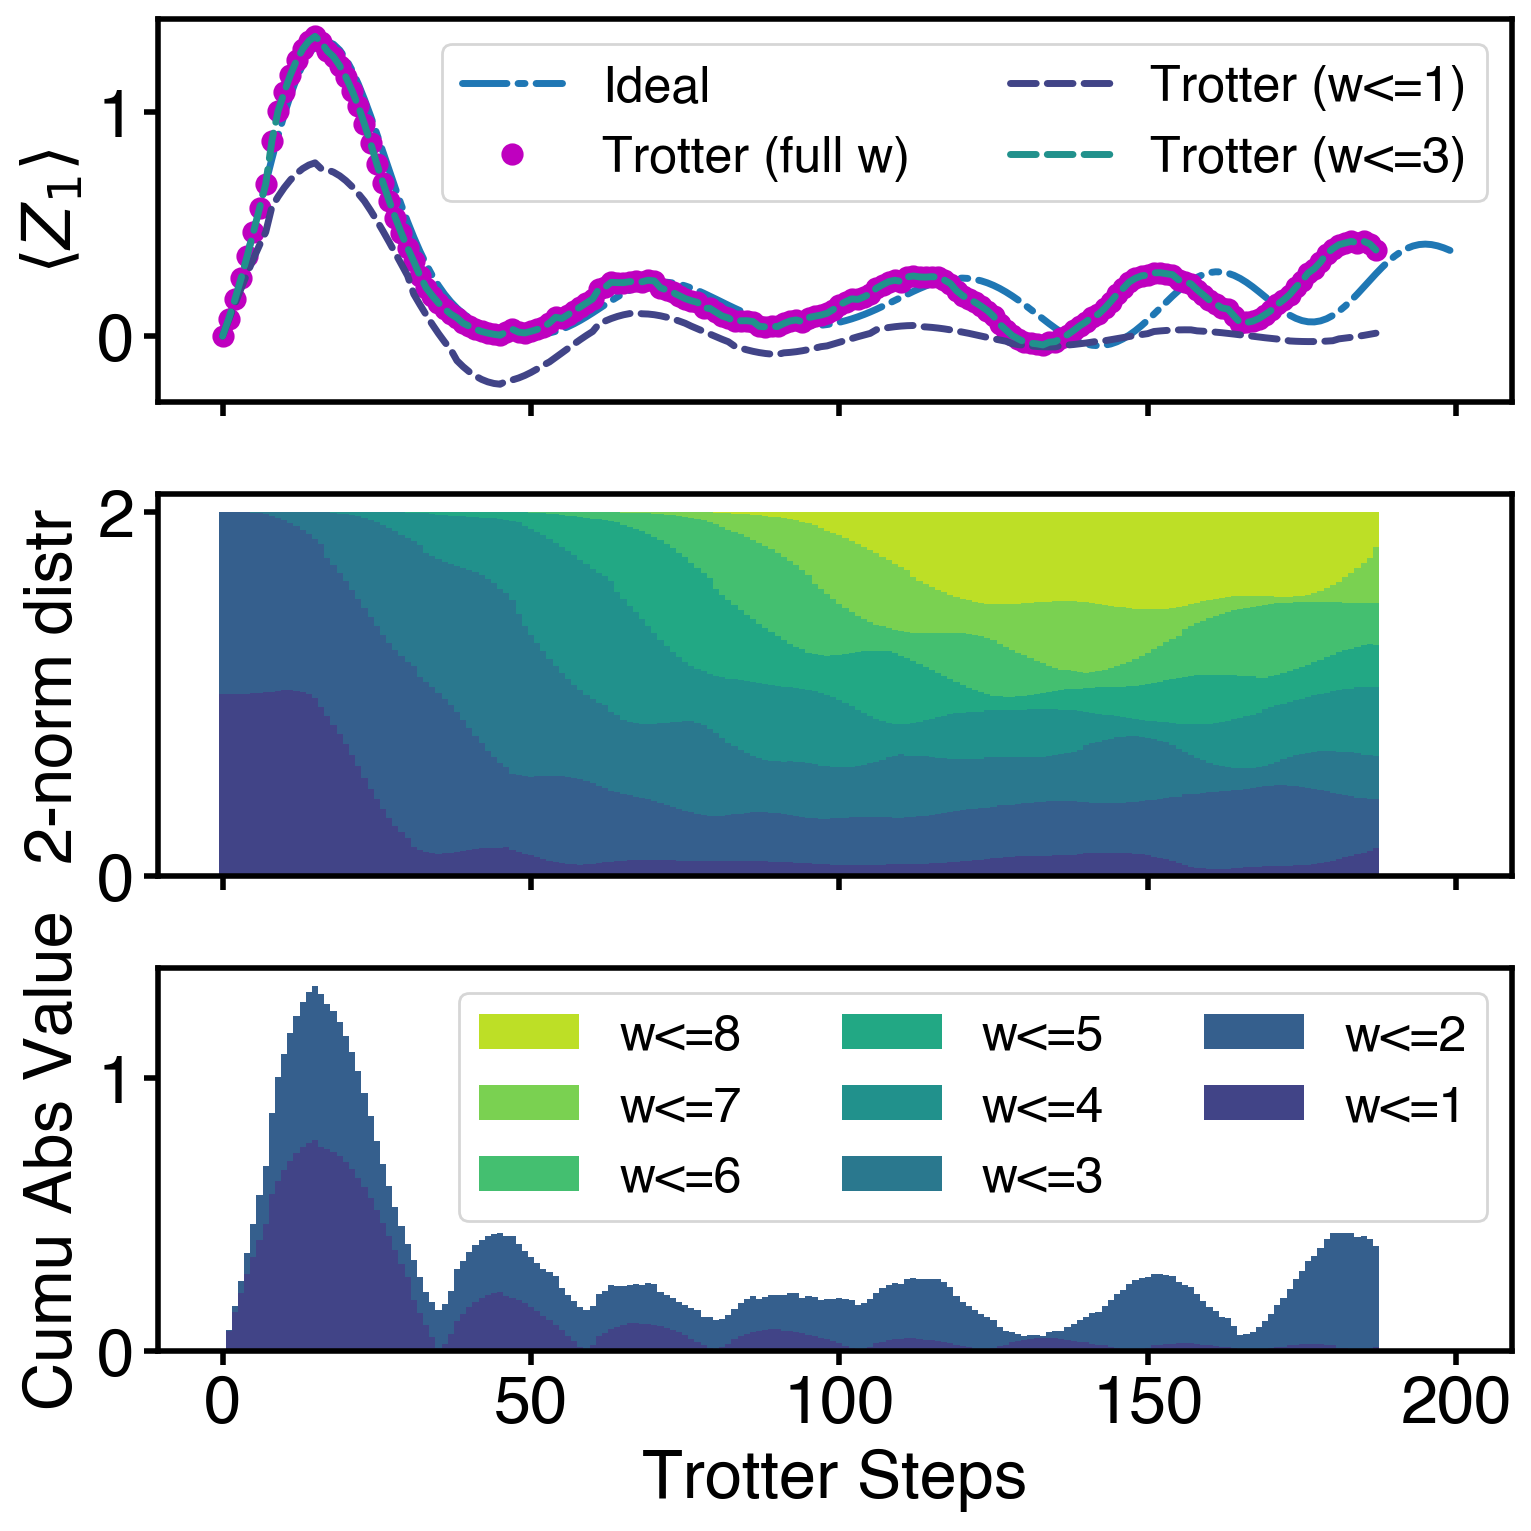

In [154]:
t_list = list(range(len(expvals)))

# Use wider spacing between bars for better visibility
x_pos = np.arange(len(expvals_w)) 
bar_width = 1.0
k = n
# colors = plt.cm.viridis(np.linspace(0.9, 0.1, k))
# colors = plt.cm.viridis(np.linspace(0.0, 1, k))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, k))

fig, [ax, ax3, ax2] = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
ax.plot(range(len(ideal_expvals)), ideal_expvals, '-.', label='Ideal')
ax.plot(t_list, expvals, '.', label='Trotter (full w)', c='m')
ax.plot(t_list, expvals_low[:, 0], '--', label='Trotter (w<=1)', color=colors[0])
ax.plot(t_list, expvals_low[:, 1], '--', label='Trotter (w<=3)', color=colors[3])
# ax.plot(t_list, expvals_low[:, 5], '--', label='Trotter (w<=5)', color=colors[5])
# ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'$\langle Z_1 \rangle$')
ax.legend(loc='upper right', ncol=2, fontsize='medium')

# Plot with different alpha values for better layering effect
for w in range(n, 0, -1):
    cumulative_values = [sum(expvals_w[i][:w]) for i in range(len(expvals_w))]
    # Vary alpha based on w value
    # alpha = 0.6 + (w / n) * 0.4
    alpha = 1
    bars = ax2.bar(x_pos, cumulative_values, bar_width, color=colors[w-1], alpha=alpha, label=f'w<={w}')
# for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(expvals_w))]
    bars = ax3.bar(x_pos, norm2_distr, bar_width, color=colors[w-1], label=f'w<={w}')

# ax2.set_xlabel('Trotter Steps')
ax2.set_ylabel('Cumu Abs Value')
# ax2.set_title('Cumulative Values with Enhanced Visibility')
ax2.legend(loc='upper right', ncol=3, fontsize='medium')  # make legend horizontal

ax2.set_xlabel('Trotter Steps')
ax3.set_ylabel('2-norm distr') # ax3.legend(loc='upper right')

fig.savefig(f'{fig_dir}/expvals_pauli.pdf', bbox_inches='tight')

norm_weight_steps: [[1.0, 1.0, 0, 0, 0, 0, 0, 0], [1.0000209489808225, 0.9999790510191775, 0, 0, 0, 0, 0, 0], [1.0001814226773924, 0.9996317403690785, 0.00018683695352863014, 0, 0, 0, 0, 0], [1.0006887226214014, 0.9985808327541053, 0.0007304338649076543, 1.0759792488277703e-08, 0, 0, 0, 0], [1.0017816765338718, 0.9962494154484095, 0.0019688141872421703, 9.383051283962442e-08, 4.3505756510723055e-13, 0, 0, 0], [1.0036580972809943, 0.99207228453723, 0.004269126621030906, 4.915545006337152e-07, 6.7408702845783305e-12, 0, 0, 0], [1.006396964232906, 0.9855885595642544, 0.008012596116044953, 1.8800297335878313e-06, 5.7748814222423213e-11, 1.847907130033839e-16, 0, 0], [1.0098888042257421, 0.9765441718396173, 0.013561231337695438, 5.7922551123929354e-06, 3.426426038059433e-10, 3.7441992831475595e-15, 0, 0], [1.0137861273197215, 0.9649665739930966, 0.02123206714655115, 1.5229972456092651e-05, 1.5690453679054512e-09, 3.870156791508872e-14, 0, 0], [1.0174831425781299, 0.951199300579965, 0.031282

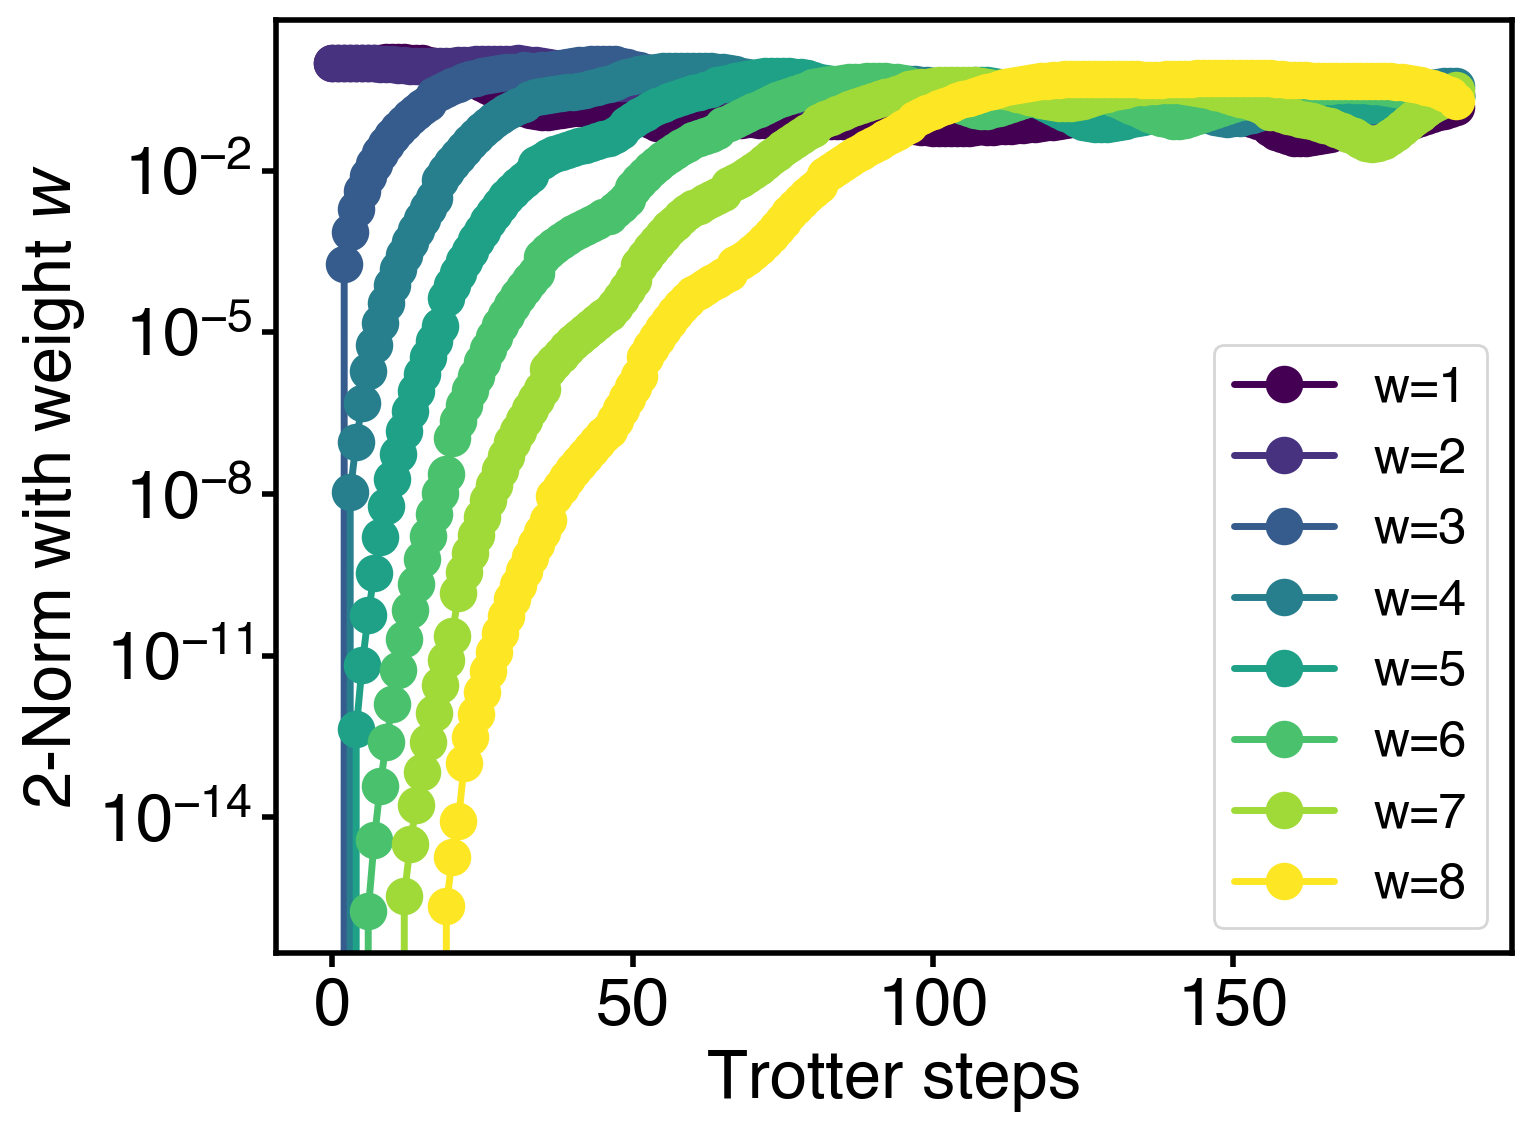

In [ ]:

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(norm_weight_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(norm_weight_steps[0])):
    ax.plot(range(len(norm_weight_steps)), np.array(norm_weight_steps)[:, w], label=f'w={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'2-Norm with weight $w$')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/norm_weight_steps.pdf', bbox_inches='tight')

In [ ]:
test = evo_ob[8]
print(test)
print(sum([coeff**2 for coeff in test.coeffs]))
# print(0.996802**2 + 0.071923**2)
c, s = math.cos(dt*2), math.sin(dt*2)

# print(c**2+s**2)
# print(c,s)
pauli_weight_norm(test)

SparsePauliOp(['IIIIIIXX', 'IIIIIIXZ', 'IIIIIIIX', 'IIIIIIIZ'],
              coeffs=[0.997409+0.j, 0.071938-0.j, 0.996802+0.j, 0.079915-0.j])
(2+0j)


{2: 0.9999999999999999, 1: 1.0000000000000002}

Text(0.5, 1.0, 'Pauli weight distribution')

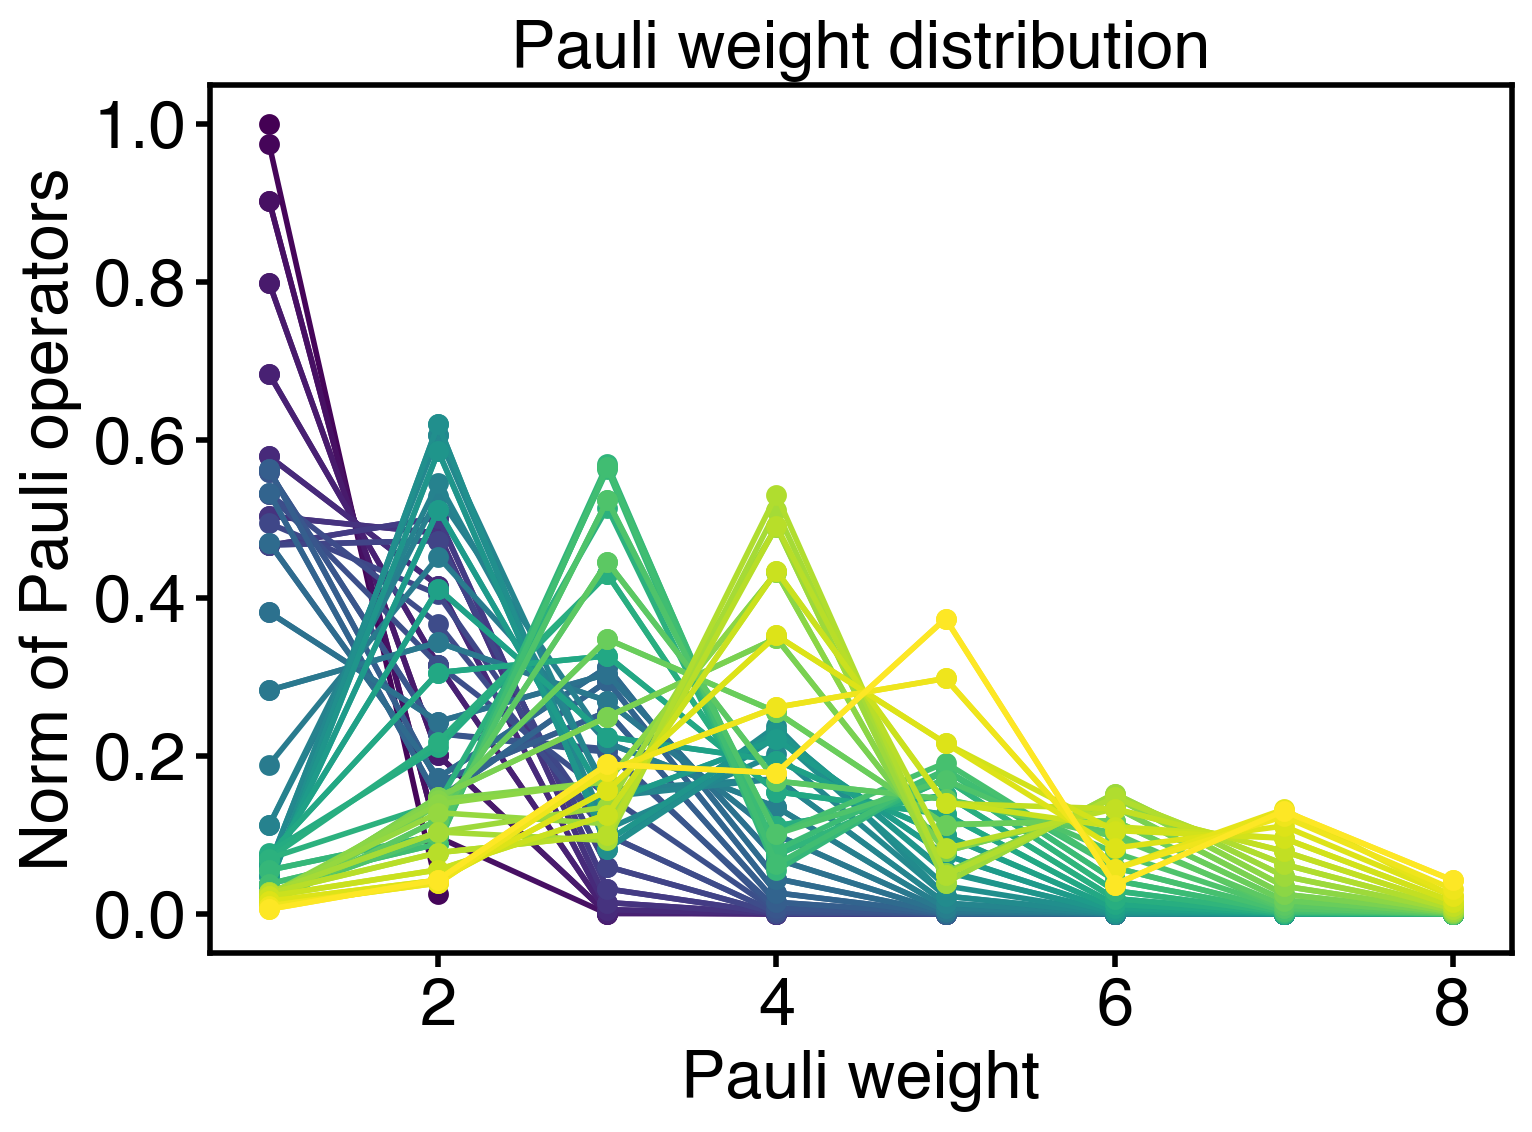

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
# use gradient color for each line
colors = plt.cm.viridis(np.linspace(0, 1, len(data_distribution)))
ax.set_prop_cycle(color=colors)
for i, item in enumerate(data_distribution):
    x = list(item.keys())
    y = [item[k] for k in x]
    ax.plot(x, y, label=f't={i*n}', marker='o', markersize=5, linewidth=2)
ax.set_xlabel('Pauli weight')
ax.set_ylabel('Norm of Pauli operators')
ax.set_title('Pauli weight distribution')